# PHASE 3 — EXPERIMENTAL DATA GENERATION (Batched)
### Mechanistic Analysis of T2I Hallucinations via Mode Interpolation

**Key upgrade:** Generates `BATCH_SIZE=4` images per DDIM loop instead of 1.
Uses ~9 GB VRAM instead of 2.2 GB → **~4× faster** → 7000 images in ~7–8 hours (one session).

**Outputs:** Everything saves to `/kaggle/working/data/` which IS Kaggle's Output tab.
After Save & Run All finishes, go to your notebook → **Output tab** → download zip.

| Section | Description |
|---------|-------------|
| 1 | Install + imports + config |
| 2 | Load SD v1.4 + verify alpha schedule |
| 3 | Batched core functions + smoke test |
| 4 | Generate 1,000 baseline images (seeds 50–99, CFG=7.5) |
| 5 | Generate 7,000 experimental images (seeds 0–49, 7 CFG values) |
| 6 | Progress report + variance preview plots |

**Before running:**
- Upload `prompt_config.json` as a Kaggle dataset (Add Data → New Dataset)
- If resuming a previous run: also upload `checkpoint.json` + any existing metadata `.json` files as a dataset
- Enable GPU: Settings → Accelerator → GPU P100
- Click **Save Version → Save & Run All (Commit)**

**Checkpointing:** Every 100 images, progress is saved to `data/checkpoint.json`.
If the 9-hour limit is hit, upload the outputs as a new dataset and re-run — done images are skipped.


In [1]:
# =============================================================================
# SECTION 1: INSTALL + IMPORTS + CONFIG
# =============================================================================

import subprocess
subprocess.run(["pip", "install", "-q", "accelerate", "ftfy"], check=True)

import torch
import numpy as np
import json
import time
import shutil
import warnings
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from diffusers import StableDiffusionPipeline, DDIMScheduler
import diffusers
import transformers

# ── CONFIG — must match Phase 2 exactly ──────────────────────────────────────
MODEL_ID          = "CompVis/stable-diffusion-v1-4"
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE             = torch.float16 if DEVICE == "cuda" else torch.float32

N_INFERENCE_STEPS = 50
VARIANCE_WINDOW   = 15          # MUST match Phase 2 — i < 15 → t = 0..14
IMAGE_SIZE        = 512

# ── BATCH SIZE ────────────────────────────────────────────────────────────────
# CFG doubles the UNet batch: BATCH_SIZE=4 → UNet sees 8 → ~9 GB VRAM.
# Safe on P100 17 GB. Smoke test in Section 3 confirms exact VRAM + speed.
# If smoke test shows VRAM > 90%, reduce to BATCH_SIZE = 2.
BATCH_SIZE = 16

EXPERIMENTAL_SEEDS = list(range(0, 50))
BASELINE_SEEDS     = list(range(50, 100))
CFG_VALUES         = [0, 1, 3, 5, 7.5, 10, 15]
BASELINE_CFG       = 7.5
CHECKPOINT_EVERY   = 100

# ── DIRECTORIES ───────────────────────────────────────────────────────────────
# /kaggle/working/ IS Kaggle's Output folder.
# Every file saved here is permanently stored when the run completes
# and downloadable from the Output tab.
ROOT = Path("/kaggle/working")
DIRS = {
    "baseline":     ROOT / "data" / "generated" / "baseline",
    "experimental": ROOT / "data" / "generated" / "experimental",
    "trajectories": ROOT / "data" / "trajectories",
    "annotations":  ROOT / "data" / "annotations",
    "figures":      ROOT / "data" / "figures",
    "data":         ROOT / "data",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE = DIRS["data"] / "checkpoint.json"

# ── LOAD PROMPT CONFIG ────────────────────────────────────────────────────────
config_path = next(
    (p for p in Path("/kaggle/input").glob("**/prompt_config.json") if p.exists()),
    None
)
if config_path is None:
    raise FileNotFoundError(
        "prompt_config.json not found. Upload via Add Data → New Dataset."
    )

with open(config_path) as f:
    PROMPT_CONFIG = json.load(f)

TOTAL_BASELINE     = len(PROMPT_CONFIG) * len(BASELINE_SEEDS)
TOTAL_EXPERIMENTAL = len(PROMPT_CONFIG) * len(EXPERIMENTAL_SEEDS) * len(CFG_VALUES)

print("=" * 55)
print("PHASE 3 — BATCHED DATA GENERATION")
print("=" * 55)
print(f"Python:        {__import__('sys').version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"diffusers:     {diffusers.__version__}")
print(f"transformers:  {transformers.__version__}")
print(f"Device:        {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:           {torch.cuda.get_device_name(0)}")
    print(f"VRAM:          {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Batch size:    {BATCH_SIZE}  (UNet sees {2*BATCH_SIZE} per step with CFG)")
print(f"Baseline:      {TOTAL_BASELINE} images")
print(f"Experimental:  {TOTAL_EXPERIMENTAL} images")
print(f"Grand total:   {TOTAL_BASELINE + TOTAL_EXPERIMENTAL} images")
print(f"Output dir:    {ROOT}/data/")
print(f"Config:        {config_path}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


PHASE 3 — BATCHED DATA GENERATION
Python:        3.12.12
PyTorch:       2.9.0+cu126
diffusers:     0.36.0
transformers:  5.2.0
Device:        cuda
GPU:           Tesla P100-PCIE-16GB
VRAM:          17.1 GB
Batch size:    16  (UNet sees 32 per step with CFG)
Baseline:      1000 images
Experimental:  7000 images
Grand total:   8000 images
Output dir:    /kaggle/working/data/
Config:        /kaggle/input/datasets/utkarshshukla040/deep-learning/prompt_config.json


In [2]:
# =============================================================================
# SECTION 2: LOAD MODEL + VERIFY ALPHA SCHEDULE
# =============================================================================
# Kaggle P100 has 16GB — no need for enable_model_cpu_offload().
# Keep attention_slicing and vae_slicing as good practice.
# Alpha verification is identical to Phase 2 — must pass before generating.

print("Loading Stable Diffusion v1.4 ...")
print("(Downloads ~4 GB from HuggingFace on first run)\n")

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

print(f"Scheduler : {type(pipe.scheduler).__name__}")
print(f"UNet      : {sum(p.numel() for p in pipe.unet.parameters())/1e6:.0f}M params")

# ── Verify alpha schedule ─────────────────────────────────────────────────────
pipe.scheduler.set_timesteps(N_INFERENCE_STEPS)
ddim_ts    = pipe.scheduler.timesteps.cpu().numpy()   # descending [981, ..., 1]
alphas_asc = [
    pipe.scheduler.alphas_cumprod[ddim_ts[N_INFERENCE_STEPS - 1 - i]].item()
    for i in range(N_INFERENCE_STEPS)
]
window_start_alpha = alphas_asc[VARIANCE_WINDOW - 1]

print(f"\nAlpha at window start (i={VARIANCE_WINDOW-1}): {window_start_alpha:.4f}")
assert 0.30 < window_start_alpha < 0.90, (
    f"Alpha {window_start_alpha:.3f} out of valid range [0.30, 0.90]!"
)
print("✅ Alpha check passed")

if torch.cuda.is_available():
    alloc = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM after loading: {alloc:.1f} / {total:.1f} GB  "
          f"({'✅ fine' if total - alloc > 4 else '⚠️ tight'})")

Loading Stable Diffusion v1.4 ...
(Downloads ~4 GB from HuggingFace on first run)



model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scheduler : DDIMScheduler
UNet      : 860M params

Alpha at window start (i=14): 0.6224
✅ Alpha check passed
VRAM after loading: 2.2 / 17.1 GB  (✅ fine)


In [3]:
# =============================================================================
# SECTION 3: BATCHED CORE FUNCTIONS
# =============================================================================
# generate_batch() runs ONE DDIM loop and produces BATCH_SIZE images at once.
#
# How batching works:
#   v1: latent (1,4,64,64) → UNet sees (2,4,64,64) with CFG → 1 image / loop
#   v2: latent (B,4,64,64) → UNet sees (2B,4,64,64) with CFG → B images / loop
#   Same 50 DDIM steps, B× more output → B× faster.
#
# All images in a batch share the same prompt + CFG, but different seeds.
# Variance is computed independently per image from its own x0 window.

@torch.no_grad()
def encode_prompt(prompt: str):
    """
    Encode once per prompt, reuse across all seeds and CFG values.
    Returns (text_emb, null_emb) — both shape (1, 77, 768) on DEVICE.
    """
    def tokenize(text):
        return pipe.tokenizer(
            [text], padding="max_length",
            max_length=pipe.tokenizer.model_max_length,
            truncation=True, return_tensors="pt",
        ).input_ids.to(DEVICE)
    return pipe.text_encoder(tokenize(prompt))[0], pipe.text_encoder(tokenize(""))[0]


@torch.no_grad()
def generate_batch(
    text_emb,
    null_emb,
    seeds: list,
    cfg_scale: float     = 7.5,
    num_steps: int       = N_INFERENCE_STEPS,
    variance_window: int = VARIANCE_WINDOW,
):
    """
    Generate len(seeds) images in one DDIM loop.
    All share the same prompt (text_emb) and cfg_scale.
    Each seed produces a different image via different initial noise.

    Window logic (Phase 1 lesson):
        step_idx ascends 0..49, but timestep t descends 981→1.
        ascending_index i = num_steps - 1 - step_idx
        Collect x0 when i < variance_window → last 15 steps.
        Converged (mode) = low variance. Hallucinating (dead zone) = high variance.

    Returns:
        variances  list[float]       one scalar per image
        images     list[np.ndarray]  each (512, 512, 3) uint8
        x0_stacks  list[np.ndarray]  each (variance_window, 4, 64, 64)
    """
    B         = len(seeds)
    scheduler = pipe.scheduler
    scheduler.set_timesteps(num_steps)
    timesteps = scheduler.timesteps  # descending [981, ..., 1]

    # B separate latents from B different seeds → (B, 4, 64, 64)
    latents = torch.stack([
        torch.randn(
            (pipe.unet.config.in_channels, IMAGE_SIZE // 8, IMAGE_SIZE // 8),
            generator=torch.Generator(device=DEVICE).manual_seed(s),
            device=DEVICE, dtype=DTYPE,
        ) for s in seeds
    ]) * scheduler.init_noise_sigma  # (B, 4, 64, 64)

    # Expand embeddings from (1,77,768) to (B,77,768)
    text_b = text_emb.expand(B, -1, -1)
    null_b = null_emb.expand(B, -1, -1)

    x0_wins = [[] for _ in range(B)]  # per-image rolling buffer

    for step_idx, t in enumerate(timesteps):

        # CFG: UNet sees (2B, 4, 64, 64)
        # Rows 0..B-1 = uncond (null), rows B..2B-1 = cond (text)
        noise_both = pipe.unet(
            torch.cat([latents, latents]),               # (2B, 4, 64, 64)
            t,
            encoder_hidden_states=torch.cat([null_b, text_b]),  # (2B, 77, 768)
        ).sample                                          # (2B, 4, 64, 64)

        noise_uncond, noise_cond = noise_both[:B], noise_both[B:]
        noise_pred = noise_uncond + cfg_scale * (noise_cond - noise_uncond)  # (B,4,64,64)

        # x0 estimate in float32 — avoids fp16 NaN
        alpha_t = scheduler.alphas_cumprod[t].to(dtype=torch.float32)
        x0_est  = (
            latents.float() - (1.0 - alpha_t).sqrt() * noise_pred.float()
        ) / alpha_t.sqrt()  # (B, 4, 64, 64)

        # Collect window: ascending i = N-1-step_idx, collect when i < window
        if (num_steps - 1 - step_idx) < variance_window:
            x0_cpu = x0_est.cpu().numpy()  # one CPU transfer for the full batch
            for b in range(B):
                x0_wins[b].append(x0_cpu[b])

        latents = scheduler.step(noise_pred, t, latents).prev_sample

    # Per-image variance
    variances, x0_stacks = [], []
    for b in range(B):
        stack = np.array(x0_wins[b])  # (variance_window, 4, 64, 64)
        variances.append(float(np.var(stack, axis=0).mean()))
        x0_stacks.append(stack)

    # Decode all B images in one VAE call
    decoded = pipe.vae.decode(
        latents.to(DTYPE) / pipe.vae.config.scaling_factor
    ).sample  # (B, 3, 512, 512)
    decoded = (decoded.float().clamp(-1, 1) + 1) / 2.0
    images  = [
        (decoded[b].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        for b in range(B)
    ]

    torch.cuda.empty_cache()
    return variances, images, x0_stacks


# ── Checkpoint helpers ────────────────────────────────────────────────────────
def load_checkpoint() -> set:
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE) as f:
            return set(json.load(f).get("completed", []))
    return set()

def save_checkpoint(completed: set):
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump({"completed": list(completed), "count": len(completed)}, f)

def img_key(split, pid, seed, cfg) -> str:
    return f"{split}__{pid}__s{seed:03d}__cfg{cfg:.1f}"

def img_path(split, pid, seed, cfg) -> Path:
    return DIRS[split] / f"{img_key(split, pid, seed, cfg)}.png"

def var_path(split, pid, seed, cfg) -> Path:
    return DIRS["trajectories"] / f"{img_key(split, pid, seed, cfg)}.npy"


# ── SMOKE TEST — confirms VRAM + speed before the full run ────────────────────
print(f"Smoke test — batch of {BATCH_SIZE} images ...")
torch.cuda.reset_peak_memory_stats()
t_smoke = time.time()
_te, _ne = encode_prompt("A red apple")
_vs, _is, _xs = generate_batch(_te, _ne, seeds=list(range(BATCH_SIZE)), cfg_scale=7.5)
smoke_secs = time.time() - t_smoke

assert all(np.isfinite(v) and v > 1e-10 for v in _vs), "Variance sanity check failed"
assert all(i.shape == (512, 512, 3) for i in _is), "Image shape check failed"

peak_gb  = torch.cuda.max_memory_allocated() / 1e9
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
spi      = smoke_secs / BATCH_SIZE          # seconds per image
t_exp_h  = TOTAL_EXPERIMENTAL * spi / 3600  # projected hours for 7000 images

print(f"\n✅ Smoke test passed")
print(f"   {BATCH_SIZE} images in {smoke_secs:.1f}s  =  {spi:.1f}s / image")
print(f"   Peak VRAM: {peak_gb:.1f} / {total_gb:.1f} GB  ({100*peak_gb/total_gb:.0f}%)")
print(f"   Projected: 7000 experimental images ≈ {t_exp_h:.1f} hours")

if t_exp_h < 9:
    print(f"   ✅ Fits within Kaggle's 9-hour Save & Run limit")
elif t_exp_h < 12:
    print(f"   ⚠️  Close to the 9-hour limit — may need 2 sessions, checkpointing handles resume")
else:
    print(f"   ⚠️  Needs 2 sessions. Checkpointing will resume from where it stopped.")

if peak_gb > total_gb * 0.90:
    print(f"   ⚠️  VRAM > 90% — set BATCH_SIZE = 2 in Section 1 and re-run from top")
else:
    print(f"   ✅ VRAM safe — good to proceed")

del _te, _ne, _vs, _is, _xs
torch.cuda.empty_cache()


Smoke test — batch of 16 images ...

✅ Smoke test passed
   16 images in 194.9s  =  12.2s / image
   Peak VRAM: 4.7 / 17.1 GB  (28%)
   Projected: 7000 experimental images ≈ 23.7 hours
   ⚠️  Needs 2 sessions. Checkpointing will resume from where it stopped.
   ✅ VRAM safe — good to proceed


In [4]:
# =============================================================================
# SECTION 4: GENERATE BASELINE IMAGES
# =============================================================================
# 20 prompts × 50 seeds (50–99) × CFG=7.5 = 1,000 images
# Used in Phase 4 to calibrate per-category thresholds:
#   T_var(category)  = mean_var(baseline) + 2 * std_var(baseline)
#   T_clip(category) = mean_clip(baseline) − 2 * std_clip(baseline)
#
# All outputs saved to /kaggle/working/data/ → visible in Output tab.

print("=" * 55)
print("SECTION 4 — BASELINE GENERATION")
print("=" * 55)

# ── STEP 1: Restore checkpoint from previous session (if uploaded as dataset) ─
# If you uploaded checkpoint.json from a previous run as a Kaggle dataset,
# this copies it into the working directory so resume works correctly.
ckpt_input = next(Path("/kaggle/input").glob("**/checkpoint.json"), None)
if ckpt_input and not CHECKPOINT_FILE.exists():
    shutil.copy(ckpt_input, CHECKPOINT_FILE)
    print(f"✅ Checkpoint restored from {ckpt_input}")
else:
    print("No previous checkpoint found — starting fresh.")

# ── STEP 2: Restore previous metadata files (critical — prevents data loss) ───
# If baseline_metadata.json exists in a dataset (from a previous session),
# copy it into annotations/ so it is not overwritten with an empty file.
for meta_name in ["baseline_metadata.json", "experimental_metadata.json",
                  "experimental_metadata_partial.json"]:
    meta_input = next(Path("/kaggle/input").glob(f"**/{meta_name}"), None)
    meta_dest  = DIRS["annotations"] / meta_name
    if meta_input and not meta_dest.exists():
        shutil.copy(meta_input, meta_dest)
        print(f"✅ Restored {meta_name} from {meta_input}")

# ── STEP 3: Load checkpoint + count progress ──────────────────────────────────
completed   = load_checkpoint()
n_done_prev = sum(1 for k in completed if k.startswith("baseline"))
print(f"\nBaseline already done: {n_done_prev} / {TOTAL_BASELINE}")
if n_done_prev == TOTAL_BASELINE:
    print("✅ Baseline complete — no new images to generate in this section.")

# ── STEP 4: Load any existing baseline metadata (preserve across sessions) ────
baseline_meta_path = DIRS["annotations"] / "baseline_metadata.json"
if baseline_meta_path.exists():
    with open(baseline_meta_path) as f:
        baseline_log = json.load(f)
    print(f"Loaded {len(baseline_log)} existing baseline metadata entries.")
else:
    baseline_log = []

# ── STEP 5: Generate missing baseline images ──────────────────────────────────
n_new = 0
t0    = time.time()

for pcfg in tqdm(PROMPT_CONFIG, desc="Baseline"):
    pid, prompt = pcfg["id"], pcfg["prompt"]
    text_emb, null_emb = encode_prompt(prompt)

    # Only process seeds not yet done
    pending = [s for s in BASELINE_SEEDS
               if img_key("baseline", pid, s, BASELINE_CFG) not in completed]

    for i in range(0, len(pending), BATCH_SIZE):
        batch_seeds = pending[i : i + BATCH_SIZE]
        variances, images, x0_stacks = generate_batch(
            text_emb, null_emb, seeds=batch_seeds, cfg_scale=BASELINE_CFG
        )

        for seed, var, img, x0 in zip(batch_seeds, variances, images, x0_stacks):
            key = img_key("baseline", pid, seed, BASELINE_CFG)
            Image.fromarray(img).save(img_path("baseline", pid, seed, BASELINE_CFG))
            np.save(var_path("baseline", pid, seed, BASELINE_CFG), x0)
            baseline_log.append({
                "key": key, "split": "baseline",
                "prompt_id": pid, "category": pcfg["category"],
                "prompt": prompt, "seed": seed,
                "cfg": BASELINE_CFG, "variance": var,
            })
            completed.add(key)
            n_new += 1

        if n_new > 0 and n_new % CHECKPOINT_EVERY == 0:
            save_checkpoint(completed)
            with open(baseline_meta_path, "w") as f:
                json.dump(baseline_log, f, indent=2)
            elapsed = time.time() - t0
            done    = n_done_prev + n_new
            rate    = n_new / elapsed
            remain  = (TOTAL_BASELINE - done) / rate if rate else 0
            print(f"  [{done}/{TOTAL_BASELINE}]  elapsed={elapsed/60:.1f}m  remaining~{remain/60:.1f}m")

# ── STEP 6: Final save ────────────────────────────────────────────────────────
save_checkpoint(completed)
with open(baseline_meta_path, "w") as f:
    json.dump(baseline_log, f, indent=2)

total_base = sum(1 for k in completed if k.startswith("baseline"))
elapsed    = time.time() - t0
print(f"\nBaseline: {total_base}/{TOTAL_BASELINE} done  |  "
      f"new this run: {n_new}  |  {elapsed/60:.1f} min")
print(f"Metadata entries: {len(baseline_log)}")
print(f"Saved to: {DIRS['baseline']}")


SECTION 4 — BASELINE GENERATION
✅ Checkpoint restored from /kaggle/input/datasets/utkarshshukla040/deep-learning/checkpoint.json
✅ Restored baseline_metadata.json from /kaggle/input/datasets/utkarshshukla040/deep-learning/baseline_metadata.json
✅ Restored experimental_metadata_partial.json from /kaggle/input/datasets/utkarshshukla040/deep-learning/experimental_metadata_partial.json

Baseline already done: 1000 / 1000
✅ Baseline complete — no new images to generate in this section.
Loaded 1000 existing baseline metadata entries.


Baseline:   0%|          | 0/20 [00:00<?, ?it/s]


Baseline: 1000/1000 done  |  new this run: 0  |  0.0 min
Metadata entries: 1000
Saved to: /kaggle/working/data/generated/baseline


In [5]:
# =============================================================================
# SECTION 5: GENERATE EXPERIMENTAL IMAGES
# =============================================================================
# 20 prompts × 50 seeds (0–49) × 7 CFG values = 7,000 images
#
# Loop order: prompt → CFG → seeds (batched)
#   All images in a batch must share the same CFG (scalar in the DDIM loop).
#   Seeds are independent so they batch freely.
#   Encoding once per prompt saves ~7 min vs re-encoding 350 times per prompt.
#
# All outputs saved to /kaggle/working/data/ → visible in Output tab.

print("=" * 55)
print("SECTION 5 — EXPERIMENTAL GENERATION")
print("=" * 55)

# ── Load checkpoint + existing partial metadata ───────────────────────────────
completed   = load_checkpoint()
n_done_prev = sum(1 for k in completed if k.startswith("experimental"))
if n_done_prev:
    print(f"Resuming: {n_done_prev} / {TOTAL_EXPERIMENTAL} already done\n")

# Load existing metadata to preserve entries from previous sessions
exp_meta_path     = DIRS["annotations"] / "experimental_metadata.json"
exp_partial_path  = DIRS["annotations"] / "experimental_metadata_partial.json"

if exp_meta_path.exists():
    with open(exp_meta_path) as f:
        exp_log = json.load(f)
    print(f"Loaded {len(exp_log)} existing experimental metadata entries.")
elif exp_partial_path.exists():
    with open(exp_partial_path) as f:
        exp_log = json.load(f)
    print(f"Loaded {len(exp_log)} existing partial metadata entries.")
else:
    exp_log = []

# ── Generate missing experimental images ─────────────────────────────────────
n_new = 0
t0    = time.time()

for pcfg in tqdm(PROMPT_CONFIG, desc="Prompts"):
    pid, prompt = pcfg["id"], pcfg["prompt"]

    # Encode once per prompt — reused for all 50 seeds × 7 CFGs = 350 combos
    text_emb, null_emb = encode_prompt(prompt)

    for cfg in CFG_VALUES:
        # Only generate seeds not yet done for this (prompt, cfg) combo
        pending = [s for s in EXPERIMENTAL_SEEDS
                   if img_key("experimental", pid, s, cfg) not in completed]

        for i in range(0, len(pending), BATCH_SIZE):
            batch_seeds = pending[i : i + BATCH_SIZE]
            variances, images, x0_stacks = generate_batch(
                text_emb, null_emb, seeds=batch_seeds, cfg_scale=cfg
            )

            for seed, var, img, x0 in zip(batch_seeds, variances, images, x0_stacks):
                key = img_key("experimental", pid, seed, cfg)
                Image.fromarray(img).save(img_path("experimental", pid, seed, cfg))
                np.save(var_path("experimental", pid, seed, cfg), x0)
                exp_log.append({
                    "key": key, "split": "experimental",
                    "prompt_id": pid, "category": pcfg["category"],
                    "prompt": prompt, "seed": seed,
                    "cfg": cfg, "variance": var,
                })
                completed.add(key)
                n_new += 1

            if n_new > 0 and n_new % CHECKPOINT_EVERY == 0:
                save_checkpoint(completed)
                # Save partial metadata every checkpoint — protects against timeout
                with open(exp_partial_path, "w") as f:
                    json.dump(exp_log, f)
                elapsed = time.time() - t0
                done    = n_done_prev + n_new
                rate    = n_new / elapsed
                remain  = (TOTAL_EXPERIMENTAL - done) / rate if rate else 0
                print(f"  [{done}/{TOTAL_EXPERIMENTAL}]  "
                      f"elapsed={elapsed/60:.1f}m  remaining~{remain/60:.1f}m  "
                      f"last_var={exp_log[-1]['variance']:.5f}")

# ── Final save ────────────────────────────────────────────────────────────────
save_checkpoint(completed)
with open(exp_meta_path, "w") as f:
    json.dump(exp_log, f, indent=2)

total_exp = sum(1 for k in completed if k.startswith("experimental"))
elapsed   = time.time() - t0

print(f"\nExperimental: {total_exp}/{TOTAL_EXPERIMENTAL}  |  "
      f"new this run: {n_new}  |  {elapsed/60:.1f} min")
print(f"Metadata entries: {len(exp_log)}")
print(f"Saved to: {DIRS['experimental']}")

if total_exp < TOTAL_EXPERIMENTAL:
    remaining = TOTAL_EXPERIMENTAL - total_exp
    print(f"\n⚠️  {remaining} images still remaining.")
    print("   Download outputs from this version's Output tab.")
    print("   Upload checkpoint.json + metadata .json files as a new dataset.")
    print("   Run a new Save Version — Section 4 & 5 will resume automatically.")
else:
    print("\n✅ All 7,000 experimental images complete.")


SECTION 5 — EXPERIMENTAL GENERATION
Resuming: 5800 / 7000 already done

Loaded 5800 existing partial metadata entries.


Prompts:   0%|          | 0/20 [00:00<?, ?it/s]

  [5900/7000]  elapsed=20.4m  remaining~224.9m  last_var=0.00254
  [6000/7000]  elapsed=40.9m  remaining~204.4m  last_var=0.00415
  [6100/7000]  elapsed=61.3m  remaining~184.0m  last_var=0.00342
  [6200/7000]  elapsed=81.8m  remaining~163.6m  last_var=0.00260
  [6300/7000]  elapsed=102.3m  remaining~143.2m  last_var=0.00202
  [6400/7000]  elapsed=122.7m  remaining~122.7m  last_var=0.00362
  [6500/7000]  elapsed=143.1m  remaining~102.2m  last_var=0.00334
  [6600/7000]  elapsed=163.5m  remaining~81.7m  last_var=0.00365
  [6700/7000]  elapsed=183.9m  remaining~61.3m  last_var=0.00415
  [6800/7000]  elapsed=204.3m  remaining~40.9m  last_var=0.00311
  [6900/7000]  elapsed=224.8m  remaining~20.4m  last_var=0.00299
  [7000/7000]  elapsed=245.2m  remaining~0.0m  last_var=0.00250

Experimental: 7000/7000  |  new this run: 1200  |  245.2 min
Metadata entries: 7000
Saved to: /kaggle/working/data/generated/experimental

✅ All 7,000 experimental images complete.


PROGRESS REPORT
  Baseline:       1000 / 1000   (100.0%)
  Experimental:   7000 / 7000  (100.0%)
  Grand total:    8000 / 8000  (100.0%)

Variance stats (7000 images):
  min=0.00069  max=0.01835  mean=0.00311  std=0.00094
  near-zero: 0.0%  ✅ healthy


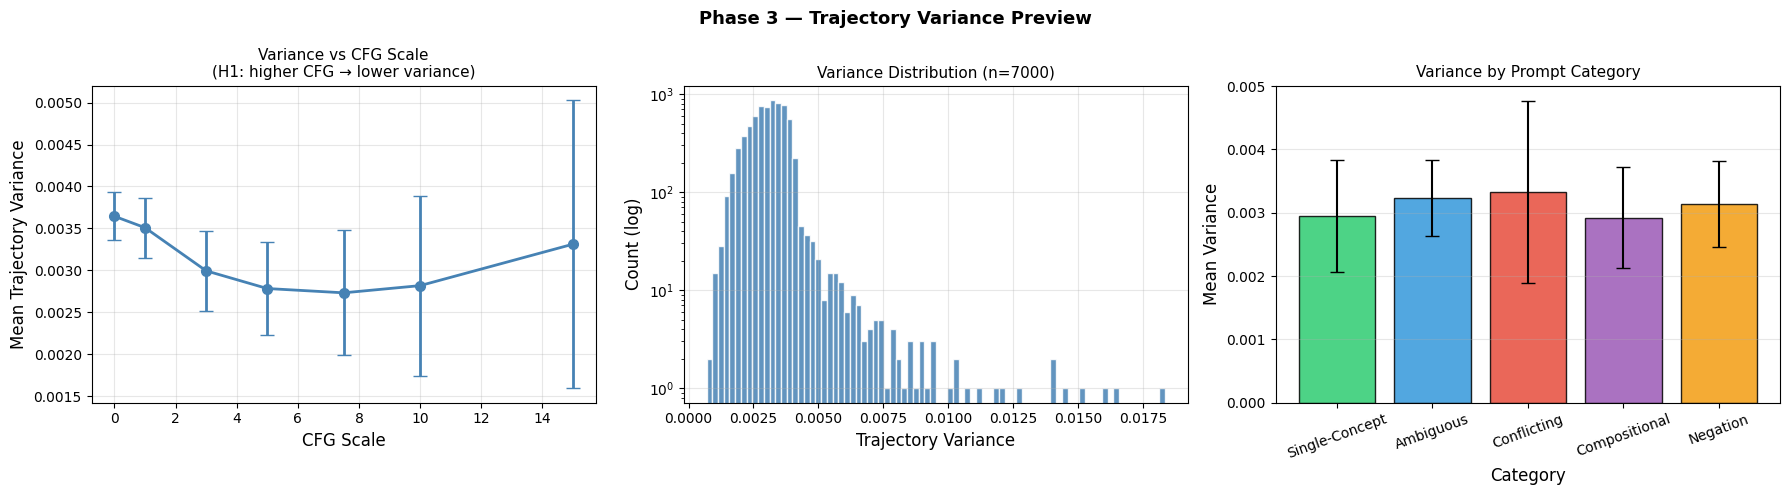

Saved: /kaggle/working/data/figures/phase3_variance_preview.png


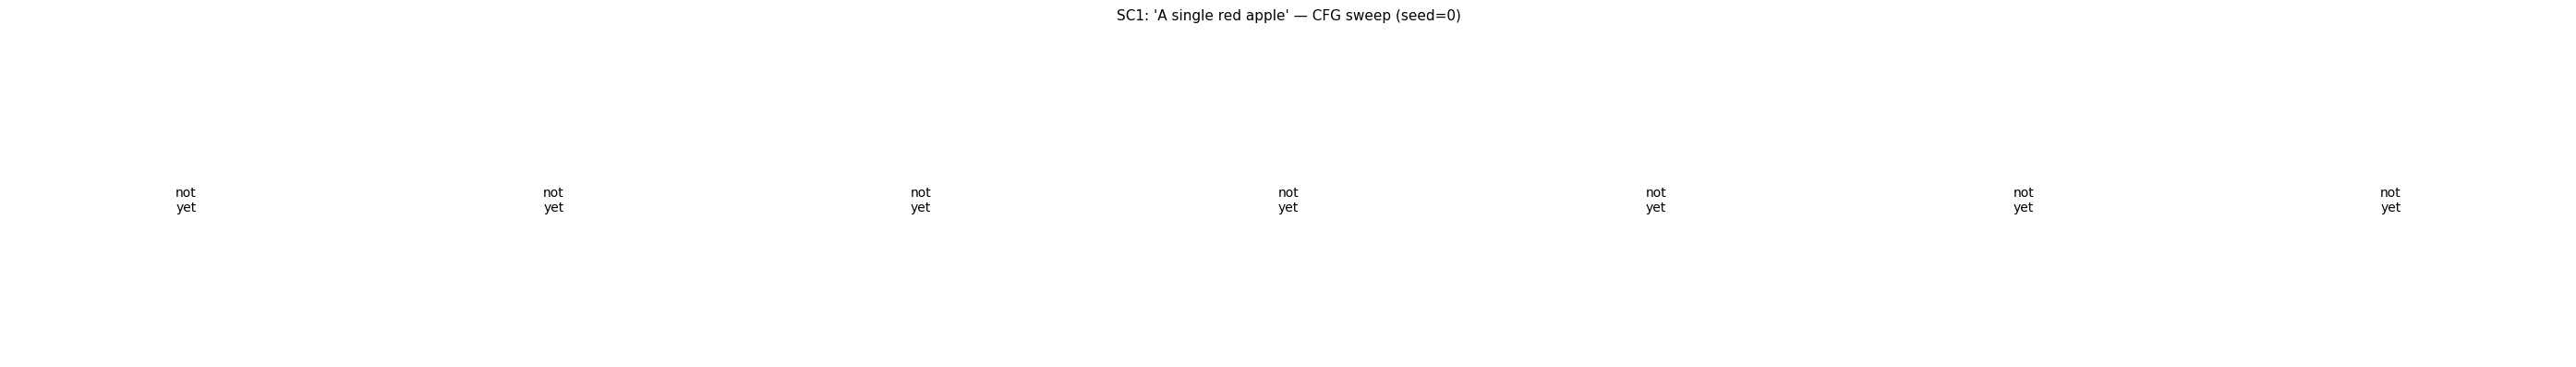


DOWNLOADING FROM KAGGLE
  Notebook → Output tab → Download All Output Files (zip)

  Files needed for Phase 4 on your local machine:
    data/generated/baseline/          ~1000 .png
    data/generated/experimental/      ~7000 .png
    data/trajectories/                ~8000 .npy  (one per image)
    data/annotations/baseline_metadata.json
    data/annotations/experimental_metadata.json
    data/checkpoint.json
  Expected total size: ~8–12 GB


In [6]:
# =============================================================================
# SECTION 6: PROGRESS REPORT + VARIANCE PREVIEW
# =============================================================================
# Run any time to check progress and get an early look at variance patterns.
# The CFG sweep plot is a preview of Figure 2 from the Implementation Plan.

completed = load_checkpoint()
n_base    = sum(1 for k in completed if k.startswith("baseline"))
n_exp     = sum(1 for k in completed if k.startswith("experimental"))

print("=" * 55)
print("PROGRESS REPORT")
print("=" * 55)
print(f"  Baseline:      {n_base:5d} / {TOTAL_BASELINE}   ({100*n_base/TOTAL_BASELINE:.1f}%)")
print(f"  Experimental:  {n_exp:5d} / {TOTAL_EXPERIMENTAL}  ({100*n_exp/TOTAL_EXPERIMENTAL:.1f}%)")
grand = n_base + n_exp
total = TOTAL_BASELINE + TOTAL_EXPERIMENTAL
print(f"  Grand total:   {grand:5d} / {total}  ({100*grand/total:.1f}%)")

# ── Load metadata ─────────────────────────────────────────────────────────────
meta = DIRS["annotations"] / "experimental_metadata.json"
if not meta.exists():
    meta = DIRS["annotations"] / "experimental_metadata_partial.json"

if not meta.exists():
    print("\nNo metadata yet — run Sections 4 & 5 first.")
else:
    with open(meta) as f:
        records = json.load(f)

    variances = np.array([r["variance"]  for r in records])
    cfgs      = np.array([r["cfg"]       for r in records])
    cats      = np.array([r["category"]  for r in records])

    print(f"\nVariance stats ({len(variances)} images):")
    print(f"  min={variances.min():.5f}  max={variances.max():.5f}  "
          f"mean={variances.mean():.5f}  std={variances.std():.5f}")
    pct_zero = (variances < 1e-5).mean() * 100
    print(f"  near-zero: {pct_zero:.1f}%  "
          f"{'✅ healthy' if pct_zero < 50 else '⚠️ check alpha regime'}")

    # ── Plot 1: Mean variance vs CFG ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cfg_present = sorted(set(cfgs.tolist()))
    axes[0].errorbar(
        cfg_present,
        [variances[cfgs == c].mean() for c in cfg_present],
        yerr=[variances[cfgs == c].std() for c in cfg_present],
        fmt="o-", color="steelblue", capsize=5, linewidth=2, markersize=7
    )
    axes[0].set_xlabel("CFG Scale", fontsize=12)
    axes[0].set_ylabel("Mean Trajectory Variance", fontsize=12)
    axes[0].set_title("Variance vs CFG Scale\n(H1: higher CFG → lower variance)", fontsize=11)
    axes[0].grid(alpha=0.3)

    # ── Plot 2: Variance histogram ────────────────────────────────────────────
    axes[1].hist(variances, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
    axes[1].set_xlabel("Trajectory Variance", fontsize=12)
    axes[1].set_ylabel("Count (log)", fontsize=12)
    axes[1].set_title(f"Variance Distribution (n={len(variances)})", fontsize=11)
    axes[1].set_yscale("log")
    axes[1].grid(alpha=0.3)

    # ── Plot 3: Mean variance by category ─────────────────────────────────────
    unique_cats = list(dict.fromkeys(cats.tolist()))
    palette     = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6", "#f39c12"]
    axes[2].bar(
        unique_cats,
        [variances[cats == c].mean() for c in unique_cats],
        yerr=[variances[cats == c].std() for c in unique_cats],
        capsize=5, color=palette[:len(unique_cats)], edgecolor="black", alpha=0.85
    )
    axes[2].set_xlabel("Category", fontsize=12)
    axes[2].set_ylabel("Mean Variance", fontsize=12)
    axes[2].set_title("Variance by Prompt Category", fontsize=11)
    axes[2].tick_params(axis="x", rotation=20)
    axes[2].grid(axis="y", alpha=0.3)

    plt.suptitle("Phase 3 — Trajectory Variance Preview", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig_path = DIRS["figures"] / "phase3_variance_preview.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")

    # ── Plot 4: Sample images at different CFG values (prompt SC1, seed 0) ────
    fig2, axes2 = plt.subplots(1, len(CFG_VALUES), figsize=(4 * len(CFG_VALUES), 4))
    for ax, cfg in zip(axes2, CFG_VALUES):
        p = img_path("experimental", "SC1", 0, cfg)
        if p.exists():
            rec = next((r for r in records if r["key"] == img_key("experimental", "SC1", 0, cfg)), None)
            ax.imshow(Image.open(p))
            ax.set_title(f"CFG={cfg}\nvar={rec['variance']:.4f}" if rec else f"CFG={cfg}", fontsize=9)
        else:
            ax.text(0.5, 0.5, "not\nyet", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
    plt.suptitle("SC1: 'A single red apple' — CFG sweep (seed=0)", fontsize=11)
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "phase3_cfg_sample_grid.png", dpi=120, bbox_inches="tight")
    plt.show()

# ── Download instructions ──────────────────────────────────────────────────────
print()
print("=" * 55)
print("DOWNLOADING FROM KAGGLE")
print("=" * 55)
print("  Notebook → Output tab → Download All Output Files (zip)")
print()
print("  Files needed for Phase 4 on your local machine:")
print("    data/generated/baseline/          ~1000 .png")
print("    data/generated/experimental/      ~7000 .png")
print("    data/trajectories/                ~8000 .npy  (one per image)")
print("    data/annotations/baseline_metadata.json")
print("    data/annotations/experimental_metadata.json")
print("    data/checkpoint.json")
print("  Expected total size: ~8–12 GB")

In [7]:
# =============================================================================
# SECTION 7: CREATE DOWNLOAD ZIP
# =============================================================================
# Packages everything into a single zip file in /kaggle/working/.
# After the run finishes, download via Kaggle CLI:
#
#   kaggle kernels output utkarshshukla070/dl-project -p ./phase3_output
#
# This downloads ONE file (diffusion_output.zip) instead of 8000+ files.
# Extract locally with: unzip diffusion_output.zip

import subprocess
import os

print("=" * 55)
print("SECTION 7 — PACKAGING OUTPUT")
print("=" * 55)

# Confirm what we have before zipping
data_dir = ROOT / "data"
n_baseline    = len(list(DIRS["baseline"].glob("*.png")))
n_experimental = len(list(DIRS["experimental"].glob("*.png")))
n_trajectories = len(list(DIRS["trajectories"].glob("*.npy")))
n_annotations  = len(list(DIRS["annotations"].glob("*.json")))

print(f"  Baseline images:      {n_baseline}")
print(f"  Experimental images:  {n_experimental}")
print(f"  Trajectory .npy:      {n_trajectories}")
print(f"  Annotation JSONs:     {n_annotations}")
print(f"  checkpoint.json:      {'✅' if (DIRS['data'] / 'checkpoint.json').exists() else '❌ MISSING'}")
print()

# Warn if experimental is incomplete
if n_experimental < TOTAL_EXPERIMENTAL:
    remaining = TOTAL_EXPERIMENTAL - n_experimental
    print(f"⚠️  {remaining} experimental images still missing.")
    print(f"   Zipping what we have — resume in the next session.")
else:
    print("✅ All 7,000 experimental images present.")

print()
print("Creating zip... (this takes ~5–10 minutes for ~8 GB)")

zip_path = "/kaggle/working/diffusion_output.zip"

# Remove old zip if it exists from a previous run
if os.path.exists(zip_path):
    os.remove(zip_path)
    print("  Removed old zip from previous run.")

result = subprocess.run(
    ["zip", "-r", zip_path, "data/"],
    cwd="/kaggle/working",
    capture_output=True, text=True
)

if result.returncode != 0:
    print(f"❌ Zip failed: {result.stderr}")
else:
    size_bytes = os.path.getsize(zip_path)
    size_gb = size_bytes / 1e9
    print(f"✅ Zip created: {zip_path}")
    print(f"   Size: {size_gb:.2f} GB")
    print()
    print("=" * 55)
    print("HOW TO DOWNLOAD")
    print("=" * 55)
    print("  1. Wait for this run to complete (Output tab shows 'Complete')")
    print("  2. On your local machine, run:")
    print("     kaggle kernels output utkarshshukla070/dl-project -p ./phase3_output")
    print()
    print("  This downloads diffusion_output.zip as a single file.")
    print("  Then extract: unzip ./phase3_output/diffusion_output.zip")
    print()
    print("  Contents after extraction:")
    print("    data/generated/baseline/          (1000 .png)")
    print("    data/generated/experimental/      (7000 .png)")
    print("    data/trajectories/                (8000 .npy)")
    print("    data/annotations/                 (metadata .json files)")
    print("    data/checkpoint.json")


SECTION 7 — PACKAGING OUTPUT
  Baseline images:      0
  Experimental images:  1200
  Trajectory .npy:      1200
  Annotation JSONs:     3
  checkpoint.json:      ✅

⚠️  5800 experimental images still missing.
   Zipping what we have — resume in the next session.

Creating zip... (this takes ~5–10 minutes for ~8 GB)
✅ Zip created: /kaggle/working/diffusion_output.zip
   Size: 1.72 GB

HOW TO DOWNLOAD
  1. Wait for this run to complete (Output tab shows 'Complete')
  2. On your local machine, run:
     kaggle kernels output utkarshshukla070/dl-project -p ./phase3_output

  This downloads diffusion_output.zip as a single file.
  Then extract: unzip ./phase3_output/diffusion_output.zip

  Contents after extraction:
    data/generated/baseline/          (1000 .png)
    data/generated/experimental/      (7000 .png)
    data/trajectories/                (8000 .npy)
    data/annotations/                 (metadata .json files)
    data/checkpoint.json
